# Ingredient Interpretation and Risky Combination Analysis

This notebook focuses on the main interpretation goal of the project: identifying which ingredients and ingredient combinations are associated with lower-rated recipes.

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

## Load Project Output Files


In [2]:
recipes = pd.read_csv("recipes_clean.csv")
long_df = pd.read_csv("recipes_ingredients_long.csv")
ingredient_summary = pd.read_csv("ingredient_summary.csv")
model_results = pd.read_csv("model_comparison_results.csv")
coef_df = pd.read_csv("champion_logistic_coefficients.csv")
pairs_df = pd.read_csv("risky_ingredient_pairs.csv")
triples_df = pd.read_csv("risky_ingredient_triples.csv")

print("recipes_clean:", recipes.shape)
print("recipes_ingredients_long:", long_df.shape)
print("ingredient_summary:", ingredient_summary.shape)
print("model_comparison_results:", model_results.shape)
print("champion_logistic_coefficients:", coef_df.shape)
print("risky_ingredient_pairs:", pairs_df.shape)
print("risky_ingredient_triples:", triples_df.shape)

recipes_clean: (14438, 16)
recipes_ingredients_long: (139238, 19)
ingredient_summary: (24309, 9)
model_comparison_results: (5, 12)
champion_logistic_coefficients: (107, 3)
risky_ingredient_pairs: (50, 11)
risky_ingredient_triples: (50, 11)


## Model Results Summary


In [3]:
model_results.sort_values(["f1", "recall"], ascending=False)

,model,threshold,num_features,accuracy,precision,recall,f1,roc_auc,true_negative,false_positive,false_negative,true_positive
0,"Additional Test: SMOTE Logistic Regression, full features",0.5,107,0.623169,0.278340,0.669100,0.393138,0.695125,1129,713,136,275
1,"Champion: Logistic Regression, full features",0.5,107,0.607190,0.273423,0.695864,0.392588,0.697487,1082,760,125,286
2,"Challenger 1: Logistic Regression, nutrition only",0.5,4,0.501997,0.211679,0.635036,0.317518,0.568568,870,972,150,261
3,"Challenger 3: Random Forest, ingredients only",0.5,100,0.777630,0.252747,0.111922,0.155143,0.597631,1706,136,365,46
4,"Challenger 2: Random Forest, full features",0.5,107,0.818464,0.562500,0.021898,0.042155,0.702927,1835,7,402,9


## Visualize Model Performance

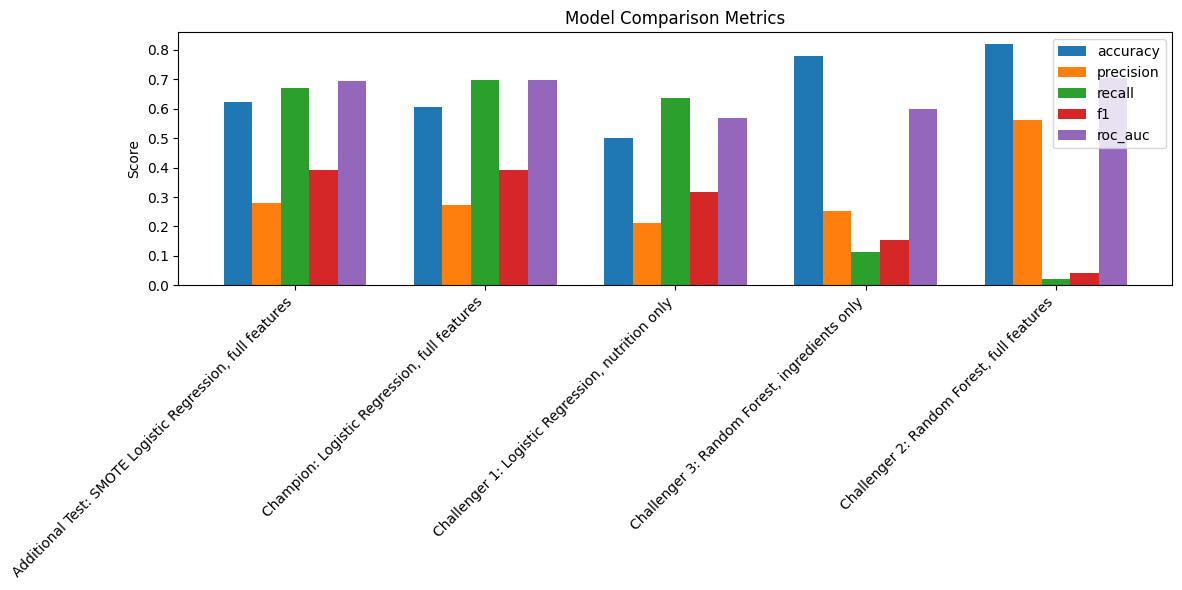

In [4]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = model_results.copy()

plt.figure(figsize=(12, 6))
positions = np.arange(len(plot_df))
width = 0.15

for i, metric in enumerate(metrics):
    plt.bar(positions + i * width, plot_df[metric], width=width, label=metric)

plt.xticks(positions + width * 2, plot_df["model"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Model Comparison Metrics")
plt.legend()
plt.tight_layout()
plt.show()

## Individual Ingredient Effects from the Champion Model

The Logistic Regression coefficients show which features are associated with a higher or lower probability of a recipe being lower-rated.

Positive coefficients mean the feature is associated with a higher chance of being lower-rated. Negative coefficients mean the feature is associated with a lower chance of being lower-rated.

In [5]:
ingredient_coef = coef_df[coef_df["feature"].str.startswith("ing_")].copy()
ingredient_coef["ingredient"] = ingredient_coef["feature"].str.replace("ing_", "", regex=False)

top_lower_rating_ingredients = (
    ingredient_coef
    .sort_values("coefficient", ascending=False)
    [["ingredient", "coefficient", "absolute_coefficient"]]
    .head(15)
)

top_lower_rating_ingredients

,ingredient,coefficient,absolute_coefficient
6,salt and pepper,0.188887,0.188887
9,water,0.156923,0.156923
12,all-purpose flour,0.121643,0.121643
13,vanilla extract,0.118983,0.118983
14,unsweetened cocoa powder,0.113892,0.113892
15,milk,0.112190,0.112190
16,parsley,0.108760,0.108760
17,garlic powder,0.108295,0.108295
19,onion,0.097055,0.097055
20,egg,0.091796,0.091796


## Ingredients Most Associated with Lower-Rated Recipes

These are the ingredients with the largest positive coefficients in the champion Logistic Regression model.

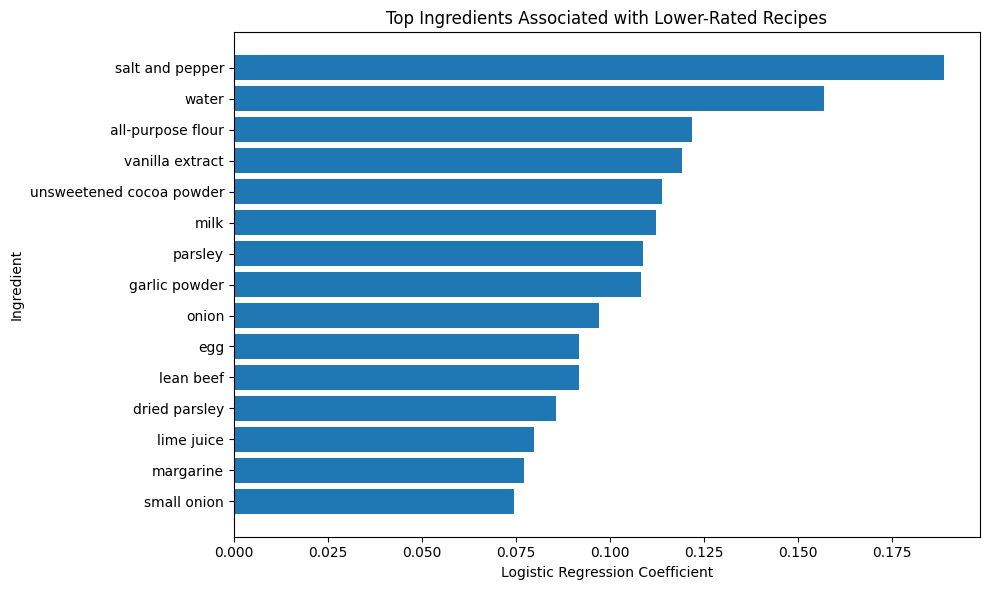

In [6]:
plot_df = top_lower_rating_ingredients.sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["ingredient"], plot_df["coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Ingredient")
plt.title("Top Ingredients Associated with Lower-Rated Recipes")
plt.tight_layout()
plt.show()

## Ingredients Most Associated with Not Being Lower-Rated

These are the ingredients with the most negative coefficients. They are associated with a lower probability of being in the lower-rated group.

In [7]:
top_not_lower_rating_ingredients = (
    ingredient_coef
    .sort_values("coefficient", ascending=True)
    [["ingredient", "coefficient", "absolute_coefficient"]]
    .head(15)
)

top_not_lower_rating_ingredients

,ingredient,coefficient,absolute_coefficient
7,extra-virgin olive oil,-0.179346,0.179346
8,kosher salt,-0.175419,0.175419
10,salt and black pepper,-0.137462,0.137462
11,heavy whipping cream,-0.122384,0.122384
18,heavy cream,-0.107945,0.107945
22,bacon,-0.090053,0.090053
23,red onion,-0.086161,0.086161
28,8 ounce package cream cheese,-0.074602,0.074602
32,italian seasoning,-0.073216,0.073216
33,white sugar,-0.070644,0.070644


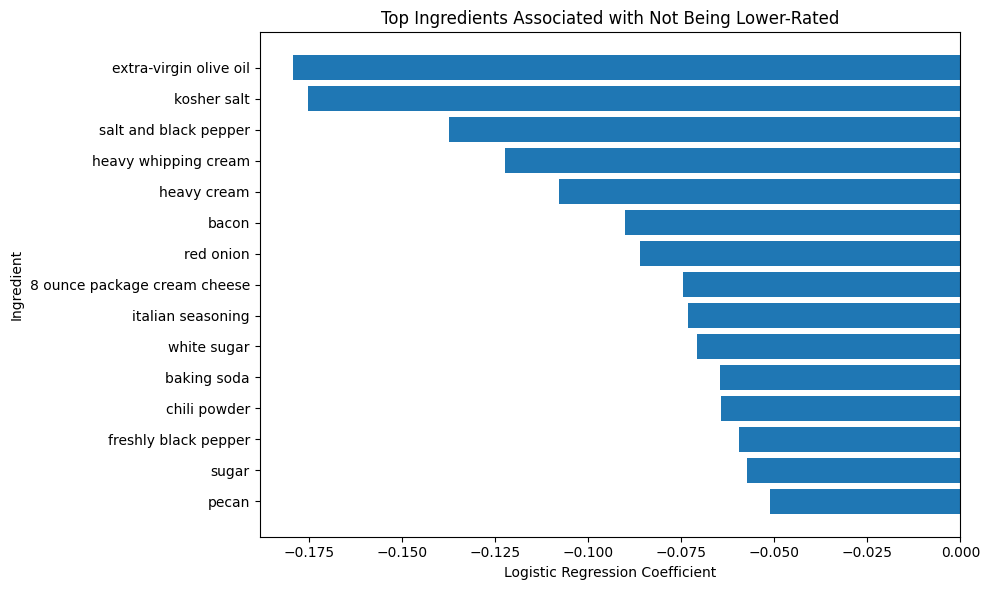

In [8]:
plot_df = top_not_lower_rating_ingredients.sort_values("coefficient", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["ingredient"], plot_df["coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Ingredient")
plt.title("Top Ingredients Associated with Not Being Lower-Rated")
plt.tight_layout()
plt.show()

## Descriptive Ingredient Summary

The model coefficients are one way to interpret ingredients. A second way is to look at simple ingredient summaries, such as average rating and recipe count.

To avoid rare ingredients dominating the results, this section filters to ingredients that appear in at least 30 recipes.

In [9]:
MIN_INGREDIENT_COUNT = 30

ingredient_summary_filtered = ingredient_summary[
    ingredient_summary["recipe_count"] >= MIN_INGREDIENT_COUNT
].copy()

lowest_avg_rating_ingredients = (
    ingredient_summary_filtered
    .sort_values(["avg_rating", "recipe_count"], ascending=[True, False])
    [["ingredient_canonical", "recipe_count", "avg_rating", "median_rating", "avg_rating_count"]]
    .head(15)
)

lowest_avg_rating_ingredients

,ingredient_canonical,recipe_count,avg_rating,median_rating,avg_rating_count
335,skim milk,42,4.222500,4.35,124.071429
373,plain greek yogurt,37,4.222857,4.50,17.891892
372,cooked white rice,37,4.238889,4.30,119.027027
193,uncooked white rice,80,4.313750,4.40,385.537500
274,black olive,52,4.322917,4.50,109.980769
344,almond milk,41,4.325000,4.50,34.268293
314,cocoa powder,45,4.334884,4.50,237.644444
334,lemon extract,42,4.345000,4.55,141.952381
198,10.75 ounce can condensed cream of mushroom soup,77,4.361039,4.40,305.337662
363,corn syrup,38,4.362162,4.60,172.131579


## Ingredients with the Lowest Average Ratings

This chart shows ingredients that appear often enough to analyze and have the lowest average recipe ratings.

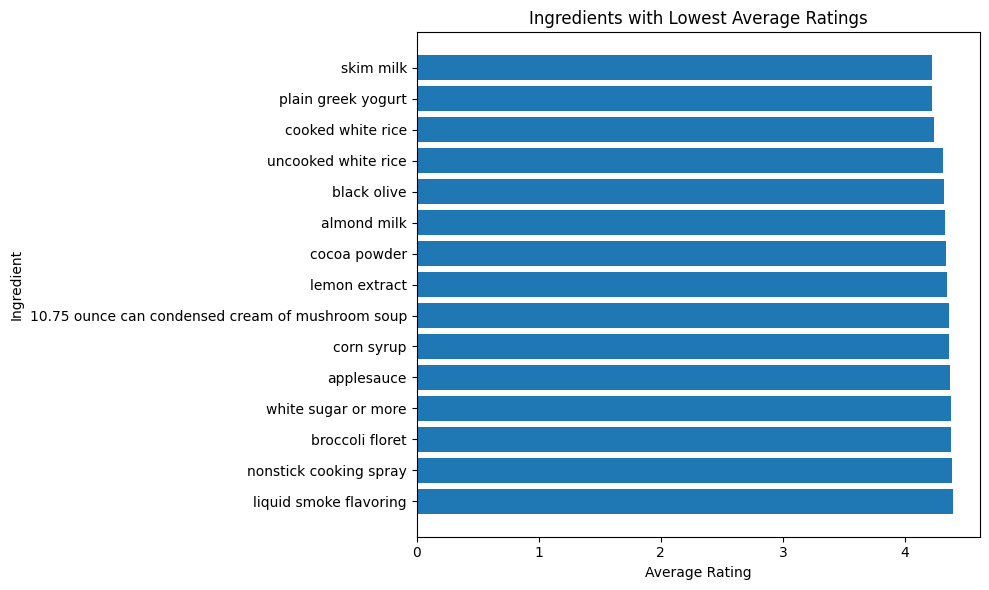

In [10]:
plot_df = lowest_avg_rating_ingredients.sort_values("avg_rating", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["ingredient_canonical"], plot_df["avg_rating"])
plt.xlabel("Average Rating")
plt.ylabel("Ingredient")
plt.title("Ingredients with Lowest Average Ratings")
plt.tight_layout()
plt.show()

## Compare Model-Based and Descriptive Ingredient Results

This table joins model coefficients with ingredient summary statistics. It helps compare whether ingredients that the model flags are also ingredients with lower average ratings.

In [11]:
coef_with_summary = ingredient_coef.merge(
    ingredient_summary,
    left_on="ingredient",
    right_on="ingredient_canonical",
    how="left"
)

coef_with_summary = coef_with_summary[
    coef_with_summary["recipe_count"].fillna(0) >= MIN_INGREDIENT_COUNT
].copy()

model_descriptive_comparison = (
    coef_with_summary
    .sort_values("coefficient", ascending=False)
    [["ingredient", "coefficient", "recipe_count", "avg_rating", "median_rating", "avg_rating_count"]]
    .head(20)
)

model_descriptive_comparison

,ingredient,coefficient,recipe_count,avg_rating,median_rating,avg_rating_count
0,salt and pepper,0.188887,630,4.475490,4.5,303.222222
3,water,0.156923,2108,4.513203,4.6,224.530361
6,all-purpose flour,0.121643,3050,4.508702,4.6,349.724590
7,vanilla extract,0.118983,2005,4.497693,4.6,287.254863
8,unsweetened cocoa powder,0.113892,220,4.462085,4.6,397.836364
9,milk,0.112190,1454,4.471277,4.6,342.922283
10,parsley,0.108760,580,4.531712,4.6,221.584483
11,garlic powder,0.108295,942,4.533333,4.6,194.109342
13,onion,0.097055,1628,4.525633,4.6,299.066953
14,egg,0.091796,2187,4.476821,4.6,317.189300


## Risky Ingredient Pairs

Ingredient pairs help answer whether certain combinations are associated with lower ratings. This matters because recipe quality can depend on how ingredients appear together, not just on individual ingredients.

The lower-rated share shows the fraction of recipes with that pair that are lower-rated. The difference-from-overall columns compare the pair to the full recipe baseline.

In [12]:
top_risky_pairs = pairs_df[
    [
        "ingredient_combo",
        "recipe_count",
        "avg_rating",
        "lower_rated_count",
        "lower_rated_share",
        "rating_difference_from_overall",
        "lower_rated_share_difference_from_overall"
    ]
].head(15)

top_risky_pairs

,ingredient_combo,recipe_count,avg_rating,lower_rated_count,lower_rated_share,rating_difference_from_overall,lower_rated_share_difference_from_overall
0,applesauce + cinnamon,21,4.3238,9,0.4286,-0.2204,0.2465
1,milk + self-rising flour,21,4.3810,9,0.4286,-0.1632,0.2465
2,rolled oat + water,21,4.4143,9,0.4286,-0.1299,0.2465
3,paprika + salt and pepper,26,4.3885,11,0.4231,-0.1557,0.2410
4,egg + unsweetened cocoa powder,54,4.3815,22,0.4074,-0.1627,0.2253
5,milk + unsweetened cocoa powder,55,4.3673,22,0.4000,-0.1769,0.2179
6,salt and pepper + water,78,4.4064,31,0.3974,-0.1378,0.2153
7,egg + onion powder,23,4.3609,9,0.3913,-0.1833,0.2092
8,paprika + parsley,21,4.4524,8,0.3810,-0.0918,0.1989
9,tomato + water,29,4.4345,11,0.3793,-0.1097,0.1972


## Visualize Risky Ingredient Pairs

These are the ingredient pairs with the highest lower-rated shares among the saved risky-pair results.

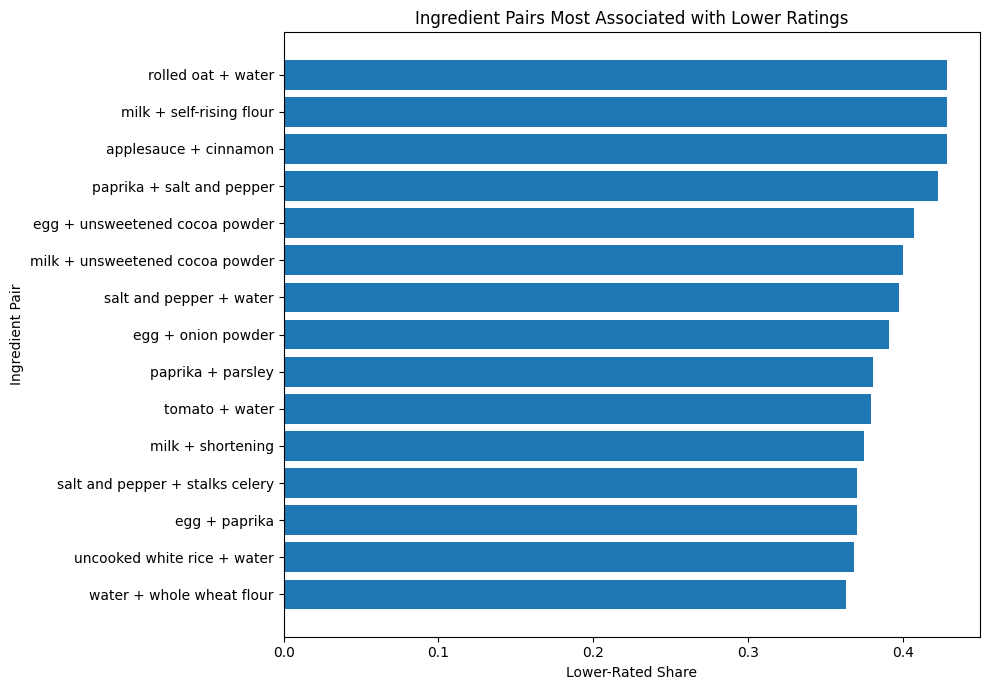

In [13]:
plot_df = top_risky_pairs.sort_values("lower_rated_share")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["ingredient_combo"], plot_df["lower_rated_share"])
plt.xlabel("Lower-Rated Share")
plt.ylabel("Ingredient Pair")
plt.title("Ingredient Pairs Most Associated with Lower Ratings")
plt.tight_layout()
plt.show()

## Risky Ingredient Triples

Ingredient triples show more specific interaction patterns. Because triples are rarer than pairs, they should be interpreted carefully and with attention to recipe count.

In [14]:
top_risky_triples = triples_df[
    [
        "ingredient_combo",
        "recipe_count",
        "avg_rating",
        "lower_rated_count",
        "lower_rated_share",
        "rating_difference_from_overall",
        "lower_rated_share_difference_from_overall"
    ]
].head(15)

top_risky_triples

,ingredient_combo,recipe_count,avg_rating,lower_rated_count,lower_rated_share,rating_difference_from_overall,lower_rated_share_difference_from_overall
0,egg + milk + unsweetened cocoa powder,16,4.2250,11,0.6875,-0.3192,0.5054
1,all-purpose flour + salt + skim milk,12,4.1500,7,0.5833,-0.3942,0.4012
2,onion + salt and pepper + stalks celery,11,4.3818,6,0.5455,-0.1624,0.3634
3,olive oil + tomato + water,13,4.3462,7,0.5385,-0.1980,0.3564
4,garlic + tomato + water,17,4.3294,9,0.5294,-0.2148,0.3473
5,carrot + egg + onion,10,4.2800,5,0.5000,-0.2642,0.3179
6,applesauce + cinnamon + vanilla extract,12,4.2917,6,0.5000,-0.2525,0.3179
7,ginger + nutmeg + water,10,4.3200,5,0.5000,-0.2242,0.3179
8,baking powder + cream cheese + salt,10,4.3400,5,0.5000,-0.2042,0.3179
9,baking powder + cream cheese + vanilla extract,10,4.3400,5,0.5000,-0.2042,0.3179


## Visualize Risky Ingredient Triples

These are the ingredient triples with the highest lower-rated shares among the saved risky-triple results.

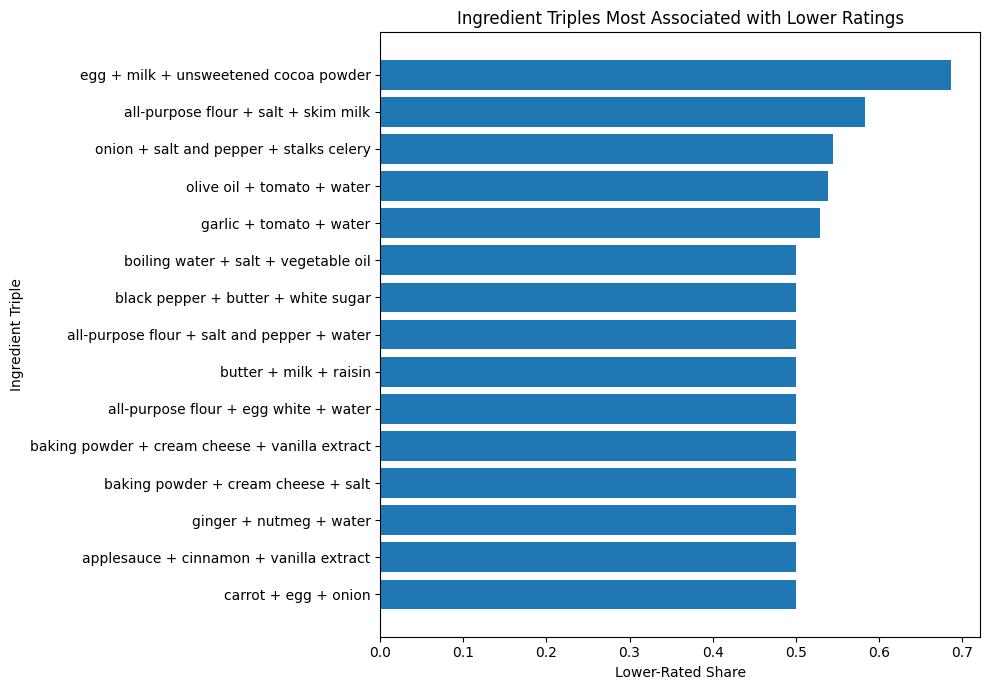

In [15]:
plot_df = top_risky_triples.sort_values("lower_rated_share")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["ingredient_combo"], plot_df["lower_rated_share"])
plt.xlabel("Lower-Rated Share")
plt.ylabel("Ingredient Triple")
plt.title("Ingredient Triples Most Associated with Lower Ratings")
plt.tight_layout()
plt.show()

## Save Final Interpretation Tables

These final tables can be used directly in the report.

In [16]:
top_lower_rating_ingredients.to_csv("final_top_lower_rating_ingredients_model.csv", index=False)
top_not_lower_rating_ingredients.to_csv("final_top_not_lower_rating_ingredients_model.csv", index=False)
lowest_avg_rating_ingredients.to_csv("final_lowest_avg_rating_ingredients.csv", index=False)
model_descriptive_comparison.to_csv("final_model_descriptive_ingredient_comparison.csv", index=False)
top_risky_pairs.to_csv("final_top_risky_pairs.csv", index=False)
top_risky_triples.to_csv("final_top_risky_triples.csv", index=False)

print("Saved final interpretation tables.")

Saved final interpretation tables.
